# Table Distribution Analysis

Reads `data/input.jsonl`, computes numeric **row totals** and **column totals** for each table, and visualises their distributions with boxplots.

In [2]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
JSONL_PATH = Path("D:\TABLE_DATASET\TableBench\TableBench.jsonl")

records = []
with JSONL_PATH.open(encoding="utf-8") as fh:
    for line in fh:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f"Loaded {len(records)} records")

Loaded 886 records


In [4]:
row_counts = []
col_counts = []

for rec in records:
    table = rec["table"]
    n_rows = len(table["data"])
    n_cols = len(table["columns"])
    row_counts.append(n_rows)
    col_counts.append(n_cols)

sizes = pd.DataFrame({"n_rows": row_counts, "n_cols": col_counts})
print(f"Tables loaded: {len(sizes)}")
print(sizes.to_string(index=True))


Tables loaded: 886
     n_rows  n_cols
0        10       5
1        10       6
2        13       6
3         9       4
4        20      13
5        10      14
6        23       4
7        30       6
8        20       7
9         7      10
10       20       5
11       11       8
12       11       9
13       17       7
14       11       7
15       25       4
16       14       5
17       12       5
18       40       5
19       24       8
20       12       6
21       10       6
22        6       5
23       11       5
24       13       6
25       28       5
26       14       7
27       43       6
28       17       4
29        8       7
30       10       5
31       18       5
32       11       5
33        7       6
34       16       6
35       19       6
36        6       8
37       10       8
38       21       8
39       12      10
40       16       5
41       24       8
42       10       7
43       16       5
44        7      10
45       23       4
46       10       5
47        7       8
4

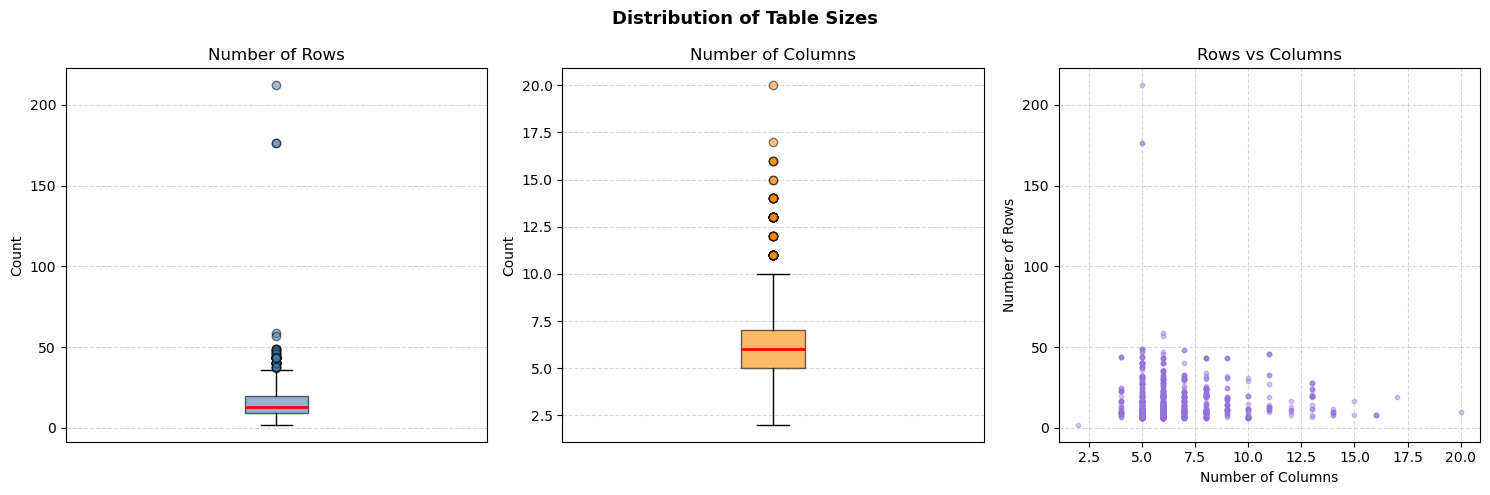

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribution of Table Sizes", fontsize=13, fontweight="bold")

for ax, data, label, color in [
    (ax1, row_counts, "Number of Rows",    "steelblue"),
    (ax2, col_counts, "Number of Columns", "darkorange"),
]:
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor=color, alpha=0.5))
    ax.set_title(label)
    ax.set_ylabel("Count")
    ax.set_xticks([])
    ax.grid(axis="y", linestyle="--", alpha=0.5)

ax3.scatter(col_counts, row_counts, alpha=0.4, s=10, color="mediumpurple")
ax3.set_title("Rows vs Columns")
ax3.set_xlabel("Number of Columns")
ax3.set_ylabel("Number of Rows")
ax3.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [8]:
sizes.describe().round(2)


,n_rows,n_cols
count,886.00,886.00
mean,16.71,6.68
std,14.20,2.13
min,2.00,2.00
25%,9.00,5.00
50%,13.00,6.00
75%,20.00,7.00
max,212.00,20.00


In [3]:
%run src/cli.py 

[table_permutation] Input : D:\TABLE_DATASET\TableBench\TableBench.jsonl
[table_permutation] Output: D:\TABLE_DATASET\TableBench\TableBench_fr0_fc0.jsonl
[table_permutation] fix_rows=0  fix_cols=0  seed=42
[table_permutation] Done – 886 entries written to D:\TABLE_DATASET\TableBench\TableBench_fr0_fc0.jsonl

[table_permutation] Input : D:\TABLE_DATASET\TableBench\TableBench.jsonl
[table_permutation] Output: D:\TABLE_DATASET\TableBench\TableBench_fr0_fcNone.jsonl
[table_permutation] fix_rows=0  fix_cols=None  seed=42
[table_permutation] Done – 886 entries written to D:\TABLE_DATASET\TableBench\TableBench_fr0_fcNone.jsonl

[table_permutation] Input : D:\TABLE_DATASET\TableBench\TableBench.jsonl
[table_permutation] Output: D:\TABLE_DATASET\TableBench\TableBench_frNone_fc0.jsonl
[table_permutation] fix_rows=None  fix_cols=0  seed=42
[table_permutation] Done – 886 entries written to D:\TABLE_DATASET\TableBench\TableBench_frNone_fc0.jsonl

[table_permutation] Input : D:\TABLE_DATASET\TableBe

In [28]:
import sys, importlib
sys.path.insert(0, "src")

# Force-reload so any edits to table_permuter.py take effect
import table_permuter
importlib.reload(table_permuter)
from table_permuter import permute_entry, _TABLE_MARKER

# ── sample entry with an instruction containing a [TABLE] block ───────────
sample = {"id": "29ba53ce7ca43a979263ed36798f62a3", "qtype": "NumericalReasoning", "qsubtype": "Aggregation", "table": {"columns": ["severe tropical cyclones", "tropical cyclones", "season", "strongest storm", "tropical lows"], "data": [["7", "11", "1993 - 94", "theodore", "12"], ["1", "3", "1992 - 93", "oliver", "6"], ["6", "9", "1994 - 95", "chloe", "19"], ["5", "12", "1999 - 00", "john / paul", "13"], ["9", "14", "1995 - 96", "olivia", "19"], ["3", "9", "1997 - 98", "tiffany", "10"], ["7", "10", "1990 - 91", "marian", "10"], ["3", "14", "1996 - 97", "pancho", "15"], ["9", "10", "1991 - 92", "jane - irna", "11"], ["9", "14", "1998 - 99", "gwenda", "21"]]}, "question": "What is the average number of tropical cyclones per season?", "answer": "10.6", "instruction_type": "DP", "instruction": "You are a table analyst. Your task is to answer questions based on the table content.\n\n\nThe answer should follow the format below:\n[Answer Format]\nFinal Answer: AnswerName1, AnswerName2...\n\nEnsure the final answer format is the last output line and can only be in the \"Final Answer: AnswerName1, AnswerName2...\" form, no other form. Ensure the \"AnswerName\" is a number or entity name, as short as possible, without any explanation.\n\n\nGive the final answer to the question directly without any explanation.\n\nRead the table below in JSON format:\n[TABLE] \n{'columns': ['season', 'tropical lows', 'tropical cyclones', 'severe tropical cyclones', 'strongest storm'], 'data': [['1990 - 91', 10, 10, 7, 'marian'], ['1991 - 92', 11, 10, 9, 'jane - irna'], ['1992 - 93', 6, 3, 1, 'oliver'], ['1993 - 94', 12, 11, 7, 'theodore'], ['1994 - 95', 19, 9, 6, 'chloe'], ['1995 - 96', 19, 14, 9, 'olivia'], ['1996 - 97', 15, 14, 3, 'pancho'], ['1997 - 98', 10, 9, 3, 'tiffany'], ['1998 - 99', 21, 14, 9, 'gwenda'], ['1999 - 00', 13, 12, 5, 'john / paul']]}\n\nLet's get start!\nQuestion: What is the average number of tropical cyclones per season?\n"}

# ── permute ────────────────────────────────────────────────────────────────
result = permute_entry(sample, fix_rows=0, fix_cols=0, seed=42)

# ── show results ───────────────────────────────────────────────────────────
print("=== entry[table] BEFORE ===")
print("columns:", sample["table"]["columns"])
print("row 0  :", sample["table"]["data"][0])

print("\n=== entry[table] AFTER ===")
print("columns:", result["table"]["columns"])
print("row 0  :", result["table"]["data"][0])

# Extract [TABLE] block from instruction
def _extract_table_block(instr):
    m = instr.find(_TABLE_MARKER)
    if m == -1:
        return "(marker not found)"
    s = m + len(_TABLE_MARKER)
    e = instr.find("\n", s)
    return instr[s:e if e != -1 else len(instr)]

print("\n=== instruction [TABLE] block BEFORE ===")
print(_extract_table_block(sample["instruction"]))

print("\n=== instruction [TABLE] block AFTER ===")
print(_extract_table_block(result["instruction"]))


=== entry[table] BEFORE ===
columns: ['severe tropical cyclones', 'tropical cyclones', 'season', 'strongest storm', 'tropical lows']
row 0  : ['7', '11', '1993 - 94', 'theodore', '12']

=== entry[table] AFTER ===
columns: ['strongest storm', 'season', 'severe tropical cyclones', 'tropical lows', 'tropical cyclones']
row 0  : ['john / paul', '1999 - 00', '5', '13', '12']

=== instruction [TABLE] block BEFORE ===
{'columns': ['season', 'tropical lows', 'tropical cyclones', 'severe tropical cyclones', 'strongest storm'], 'data': [['1990 - 91', 10, 10, 7, 'marian'], ['1991 - 92', 11, 10, 9, 'jane - irna'], ['1992 - 93', 6, 3, 1, 'oliver'], ['1993 - 94', 12, 11, 7, 'theodore'], ['1994 - 95', 19, 9, 6, 'chloe'], ['1995 - 96', 19, 14, 9, 'olivia'], ['1996 - 97', 15, 14, 3, 'pancho'], ['1997 - 98', 10, 9, 3, 'tiffany'], ['1998 - 99', 21, 14, 9, 'gwenda'], ['1999 - 00', 13, 12, 5, 'john / paul']]}

=== instruction [TABLE] block AFTER ===
{'columns': ['severe tropical cyclones', 'tropical cyclon

## Ollama inference

Run a permuted JSONL file through a locally-running Ollama model.
Results land in `<output_root>/<model_name>/<input_stem>.jsonl`, each line containing `id`, `raw_output`, and `pred_answer`.


In [ ]:
import sys, importlib
sys.path.insert(0, "src")

import ollama_runner
importlib.reload(ollama_runner)
from ollama_runner import run_jsonl

# Run on a permuted file — adjust model name and paths as needed
run_jsonl(
    input_path=r"D:\TABLE_DATASET\TableBench\TableBench_DP_fr0_fc0.jsonl",
    output_root=r"D:\TABLE_DATASET\TableBench\results",
    model="llama3",          # any model pulled in Ollama
    host="http://localhost:11434",
    timeout=120,
    workers=1,               # increase for CPU-only or multi-GPU setups
)
